# Dynamic Programming (Value Iteration & Policy Iteration)

Dynamic Programming (DP) methods solve an MDP when we **already know** the transition
probabilities and rewards (a "model" of the environment).

DP has two main algorithms:

1. **Value Iteration** - directly update the value function using the Bellman Optimality Equation until it converges.
2. **Policy Iteration** - alternate between evaluating a policy (Policy Evaluation) and improving it (Policy Improvement).

### Bellman Optimality Equation

V(s) = max_a Σ P(s'|s,a) [ R(s,a,s') + γ V(s') ]


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Grid World Setup

rows = 4
cols = 4

goal_state = (3, 3)

reward = np.full((rows, cols), -1)
reward[goal_state] = 10

reward


array([[-1, -1, -1, -1],
       [-1, -1, -1, -1],
       [-1, -1, -1, -1],
       [-1, -1, -1, 10]])

In [3]:
actions = ["UP", "DOWN", "LEFT", "RIGHT"]

def next_state(state, action):
    row, col = state

    if action == "UP":
        row = max(row - 1, 0)
    elif action == "DOWN":
        row = min(row + 1, rows - 1)
    elif action == "LEFT":
        col = max(col - 1, 0)
    elif action == "RIGHT":
        col = min(col + 1, cols - 1)

    return (row, col)


## Value Iteration

In [4]:
gamma = 0.9
theta = 1e-4

V = np.zeros((rows, cols))

def value_iteration():
    while True:
        delta = 0
        new_V = V.copy()

        for i in range(rows):
            for j in range(cols):
                state = (i, j)

                if state == goal_state:
                    continue

                values = []
                for action in actions:
                    ns = next_state(state, action)
                    r = reward[ns]
                    values.append(r + gamma * V[ns])

                new_V[state] = max(values)
                delta = max(delta, abs(new_V[state] - V[state]))

        V[:, :] = new_V

        if delta < theta:
            break

    return V

V = value_iteration()
print("Converged Value Function:")
print(V)


Converged Value Function:
[[ 1.8098  3.122   4.58    6.2   ]
 [ 3.122   4.58    6.2     8.    ]
 [ 4.58    6.2     8.     10.    ]
 [ 6.2     8.     10.      0.    ]]


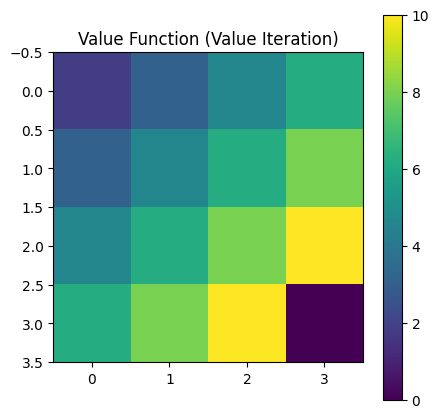

In [5]:
plt.figure(figsize=(5,5))
plt.imshow(V, cmap="viridis")
plt.colorbar()
plt.title("Value Function (Value Iteration)")
plt.show()


## Extracting the Optimal Policy from V

In [6]:
def extract_policy(V):
    policy = np.empty((rows, cols), dtype=object)

    for i in range(rows):
        for j in range(cols):
            state = (i, j)

            if state == goal_state:
                policy[state] = "GOAL"
                continue

            best_action = None
            best_value = -np.inf

            for action in actions:
                ns = next_state(state, action)
                r = reward[ns]
                val = r + gamma * V[ns]

                if val > best_value:
                    best_value = val
                    best_action = action

            policy[state] = best_action

    return policy

policy = extract_policy(V)
print(policy)


[['DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'GOAL']]


## Policy Iteration

In [7]:
def policy_evaluation(policy, V, theta=1e-4):
    while True:
        delta = 0
        new_V = V.copy()

        for i in range(rows):
            for j in range(cols):
                state = (i, j)

                if state == goal_state:
                    continue

                action = policy[state]
                ns = next_state(state, action)
                new_V[state] = reward[ns] + gamma * V[ns]
                delta = max(delta, abs(new_V[state] - V[state]))

        V[:, :] = new_V

        if delta < theta:
            break

    return V


def policy_improvement(V):
    policy = np.empty((rows, cols), dtype=object)

    for i in range(rows):
        for j in range(cols):
            state = (i, j)

            if state == goal_state:
                policy[state] = "GOAL"
                continue

            best_action = None
            best_value = -np.inf

            for action in actions:
                ns = next_state(state, action)
                val = reward[ns] + gamma * V[ns]

                if val > best_value:
                    best_value = val
                    best_action = action

            policy[state] = best_action

    return policy


In [8]:
# Policy Iteration Loop

V_pi = np.zeros((rows, cols))
policy_pi = np.full((rows, cols), "UP", dtype=object)

for iteration in range(20):
    V_pi = policy_evaluation(policy_pi, V_pi)
    new_policy = policy_improvement(V_pi)

    if np.array_equal(new_policy, policy_pi):
        print(f"Policy converged after {iteration+1} iterations")
        break

    policy_pi = new_policy

print("Final Value Function:")
print(V_pi)
print("\nFinal Policy:")
print(policy_pi)


Policy converged after 7 iterations
Final Value Function:
[[ 1.8098  3.122   4.58    6.2   ]
 [ 3.122   4.58    6.2     8.    ]
 [ 4.58    6.2     8.     10.    ]
 [ 6.2     8.     10.      0.    ]]

Final Policy:
[['DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'GOAL']]


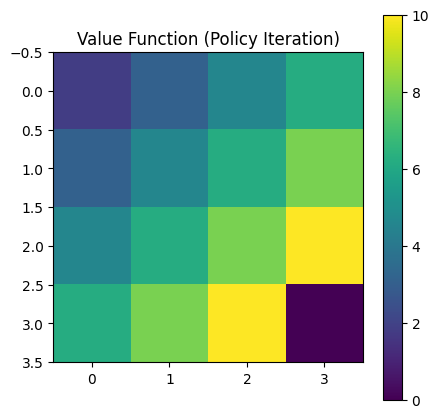

In [9]:
plt.figure(figsize=(5,5))
plt.imshow(V_pi, cmap="viridis")
plt.colorbar()
plt.title("Value Function (Policy Iteration)")
plt.show()


## Conclusion

Both Value Iteration and Policy Iteration converge to the same optimal value function and
policy for this grid world, since both are model-based methods that rely on complete
knowledge of the environment's dynamics (transition probabilities and rewards).
